In [14]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight 
from tensorflow.keras.utils import to_categorical
from ydata_profiling import ProfileReport
from tensorflow.keras.metrics import F1Score,mae

In [2]:
df=pd.read_csv('test_energy_data.csv')

In [3]:
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


In [7]:
X=df.drop("Energy Consumption",axis=1)
y=df["Energy Consumption"]
X=pd.get_dummies(X,drop_first=True)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,)

In [8]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [19]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64,activation='relu'),
    
    Dense(32,activation='relu'),

    Dense(1,activation='linear')
])
model.compile(optimizer=Adam(learning_rate=0.1), loss=mae, metrics=['mae'])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,batch_size=32)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 4145.2979 - mae: 4145.2979 - val_loss: 4284.7842 - val_mae: 4284.7842
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 4062.2214 - mae: 4062.2214 - val_loss: 4084.1497 - val_mae: 4084.1497
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3784.4500 - mae: 3784.4500 - val_loss: 3588.3438 - val_mae: 3588.3438
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3144.1978 - mae: 3144.1978 - val_loss: 2608.9673 - val_mae: 2608.9673
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1952.5605 - mae: 1952.5605 - val_loss: 1174.3235 - val_mae: 1174.3235
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 997.5953 - mae: 997.5953 - val_loss: 1027.6421 - val_mae: 1027.6421
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1320.2434 - mae: 1320.2434 - val_loss: 682.8787 - val_mae: 682.8787
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 642.8242 - mae: 642.8242 - val_loss: 607.4962 - v

C:\Users\miana\AppData\Local\Temp\ipykernel_7052\2871961737.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


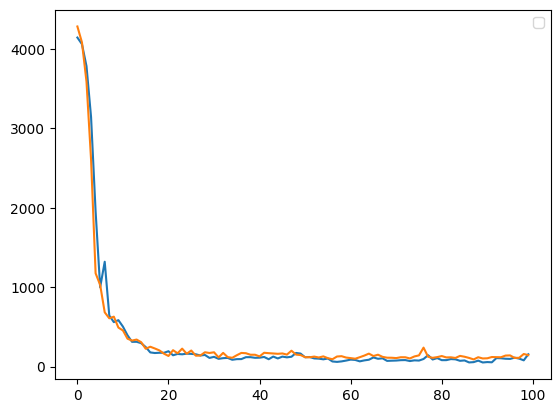

In [21]:
%matplotlib inline
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend()
plt.show()